In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tvm

SEED = 17
DEVICE = "cuda"
MODEL_NAMES = ["resnet34", "vgg11", "resnet18", "vgg16", "densenet"]
MODEL_PATHS = {n: f"../models/{n}.pth" for n in MODEL_NAMES}
ADV_PATHS = {n: f"../adv_examples/{n}.pt" for n in MODEL_NAMES}

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [20]:
import torch.nn as nn
import torchvision.models as tvm

def get_resnet34():
    m = tvm.resnet34(weights=None)
    m.fc = nn.Linear(512, 10)
    return m

def get_vgg11():
    m = tvm.vgg11(weights=None)
    m.classifier[6] = nn.Linear(4096, 10)
    return m

def get_resnet18():
    m = tvm.resnet18(weights=None)
    m.fc = nn.Linear(512, 10)
    return m

def get_vgg16():
    m = tvm.vgg16(weights=None)
    m.classifier[6] = nn.Linear(4096, 10)
    return m

def get_densenet():
    m = tvm.densenet121(weights=None)
    m.classifier = nn.Linear(1024, 10)
    return m

def get_model(name):
    return {
        "resnet34": get_resnet34,
        "vgg11": get_vgg11,
        "resnet18": get_resnet18,
        "vgg16": get_vgg16,
        "densenet": get_densenet
    }[name]()

In [21]:
adv_data = {}

for name in MODEL_NAMES:
    adv_data[name] = torch.load(ADV_PATHS[name])

In [22]:
import gc

def evaluate_transfer():
    results = {}

    for source in MODEL_NAMES:
        print(f"\n=== Source: {source} ===")
        data = adv_data[source]
        images = data['pgd']
        labels = data['labels']
        results[source] = {}

        for target in MODEL_NAMES:
            # load to GPU, evaluate, then immediately delete
            model = get_model(target).to(DEVICE)
            model.load_state_dict(torch.load(MODEL_PATHS[target], map_location=DEVICE))
            model.eval()

            correct = 0
            total = 0

            with torch.no_grad():
                for i in range(0, len(images), 128):
                    batch_imgs = images[i:i+128].to(DEVICE)
                    batch_lbls = labels[i:i+128].to(DEVICE)
                    preds = model(batch_imgs).argmax(1)
                    correct += (preds == batch_lbls).sum().item()
                    total   += batch_lbls.size(0)

            acc = 100 * correct / total
            results[source][target] = acc
            print(f"  {source} → {target}: {acc:.2f}%")

            # clearing memory immediately after each target
            # encountered OOM errors when trying to keep multiple models in memory
            del model
            gc.collect()
            torch.cuda.empty_cache()

    return results

results = evaluate_transfer()


=== Source: resnet34 ===
  resnet34 → resnet34: 0.02%
  resnet34 → vgg11: 49.55%
  resnet34 → resnet18: 22.24%
  resnet34 → vgg16: 42.24%
  resnet34 → densenet: 33.77%

=== Source: vgg11 ===
  vgg11 → resnet34: 63.57%
  vgg11 → vgg11: 0.07%
  vgg11 → resnet18: 63.74%
  vgg11 → vgg16: 56.09%
  vgg11 → densenet: 66.43%

=== Source: resnet18 ===
  resnet18 → resnet34: 21.95%
  resnet18 → vgg11: 48.88%
  resnet18 → resnet18: 0.02%
  resnet18 → vgg16: 41.11%
  resnet18 → densenet: 31.83%

=== Source: vgg16 ===
  vgg16 → resnet34: 57.48%
  vgg16 → vgg11: 54.88%
  vgg16 → resnet18: 58.15%
  vgg16 → vgg16: 0.39%
  vgg16 → densenet: 63.12%

=== Source: densenet ===
  densenet → resnet34: 48.48%
  densenet → vgg11: 61.39%
  densenet → resnet18: 46.93%
  densenet → vgg16: 60.31%
  densenet → densenet: 0.71%


In [23]:
import pandas as pd
df = pd.DataFrame(results)

In [24]:
import numpy as np
from itertools import combinations
import torchvision
import gc

CPU = 'cpu'

# ---- data loader ----
small_loader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10('../data', train=False, download=False,
                                 transform=torchvision.transforms.ToTensor()),
    batch_size=64, shuffle=False, num_workers=2)

testloader_small = list(small_loader)[:50]  # 50 batches
criterion = nn.CrossEntropyLoss()

# ---- parameter count (no GPU needed) ----
param_counts = {}
for name in MODEL_NAMES:
    m = get_model(name)
    param_counts[name] = sum(p.numel() for p in m.parameters())
    del m

# ---- gradient norm + cosine sim on CPU (avoids OOM) ----
def get_gradients(name, batches):
    """Returns flat gradients for each sample across all batches."""
    model = get_model(name).to(CPU)
    model.load_state_dict(torch.load(MODEL_PATHS[name], map_location=CPU))
    model.eval()
    all_grads = []
    for images, labels in batches:
        images = images.clone().requires_grad_(True)
        criterion(model(images), labels).backward()
        all_grads.append(images.grad.view(images.size(0), -1).detach())
    del model
    gc.collect()
    return torch.cat(all_grads)  # [N, D]

# compute gradients once per model — reuse for both norm and cosine sim
all_grads = {}
for name in MODEL_NAMES:
    all_grads[name] = get_gradients(name, testloader_small)

# gradient norms
grad_norms = {name: all_grads[name].norm(dim=1).mean().item()
              for name in MODEL_NAMES}

# cosine similarities
cosine_sims = {}
for A, B in combinations(MODEL_NAMES, 2):
    cos = nn.functional.cosine_similarity(all_grads[A], all_grads[B], dim=1)
    cosine_sims[(A, B)] = cos.mean().item()
    cosine_sims[(B, A)] = cosine_sims[(A, B)]

# ---- asymmetry scores ----
asymmetry = {}
for A, B in combinations(MODEL_NAMES, 2):
    ab = 100 - results[A][B]
    ba = 100 - results[B][A]
    asymmetry[(A, B)] = abs(ab - ba)

# ---- print everything ----
print("\n=== Parameter Counts ===")
for name in MODEL_NAMES:
    print(f"  {name}: {param_counts[name]:,}")

print("\n=== Gradient Norms ===")
for name in MODEL_NAMES:
    print(f"  {name}: {grad_norms[name]:.4f}")

print("\n=== Gradient Cosine Similarity ===")
for A, B in combinations(MODEL_NAMES, 2):
    print(f"  {A} ↔ {B}: {cosine_sims[(A,B)]:.4f}")

print("\n=== Asymmetry vs Properties ===")
for A, B in combinations(MODEL_NAMES, 2):
    norm_diff = abs(grad_norms[A] - grad_norms[B])
    cos_sim   = cosine_sims[(A, B)]
    asym      = asymmetry[(A, B)]
    print(f"  {A} ↔ {B}: norm_diff={norm_diff:.4f} | cos_sim={cos_sim:.4f} | asymmetry={asym:.2f}%")


=== Parameter Counts ===
  resnet34: 21,289,802
  vgg11: 128,807,306
  resnet18: 11,181,642
  vgg16: 134,301,514
  densenet: 6,964,106

=== Gradient Norms ===
  resnet34: 0.0667
  vgg11: 0.0982
  resnet18: 0.0693
  vgg16: 0.1032
  densenet: 0.0977

=== Gradient Cosine Similarity ===
  resnet34 ↔ vgg11: 0.1089
  resnet34 ↔ resnet18: 0.2757
  resnet34 ↔ vgg16: 0.1347
  resnet34 ↔ densenet: 0.1729
  vgg11 ↔ resnet18: 0.1140
  vgg11 ↔ vgg16: 0.1058
  vgg11 ↔ densenet: 0.0771
  resnet18 ↔ vgg16: 0.1376
  resnet18 ↔ densenet: 0.1793
  vgg16 ↔ densenet: 0.0916

=== Asymmetry vs Properties ===
  resnet34 ↔ vgg11: norm_diff=0.0315 | cos_sim=0.1089 | asymmetry=14.02%
  resnet34 ↔ resnet18: norm_diff=0.0026 | cos_sim=0.2757 | asymmetry=0.29%
  resnet34 ↔ vgg16: norm_diff=0.0365 | cos_sim=0.1347 | asymmetry=15.24%
  resnet34 ↔ densenet: norm_diff=0.0311 | cos_sim=0.1729 | asymmetry=14.71%
  vgg11 ↔ resnet18: norm_diff=0.0289 | cos_sim=0.1140 | asymmetry=14.86%
  vgg11 ↔ vgg16: norm_diff=0.0050 | 

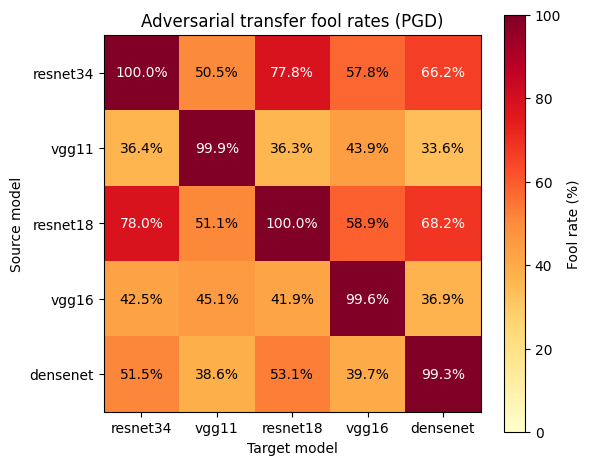

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# build fool rate matrix
n = len(MODEL_NAMES)
matrix = np.zeros((n, n))
for i, src in enumerate(MODEL_NAMES):
    for j, tgt in enumerate(MODEL_NAMES):
        matrix[i, j] = 100 - results[src][tgt]  # fool rate

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Fool rate (%)')

ax.set_xticks(range(n)); ax.set_xticklabels(MODEL_NAMES)
ax.set_yticks(range(n)); ax.set_yticklabels(MODEL_NAMES)
ax.set_xlabel("Target model")
ax.set_ylabel("Source model")
ax.set_title("Adversarial transfer fool rates (PGD)")

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matrix[i,j]:.1f}%",
                ha='center', va='center', fontsize=10,
                color='black' if matrix[i,j] < 60 else 'white')

plt.tight_layout()
plt.savefig("../results/transfer_matrix.png", dpi=150)
plt.show()

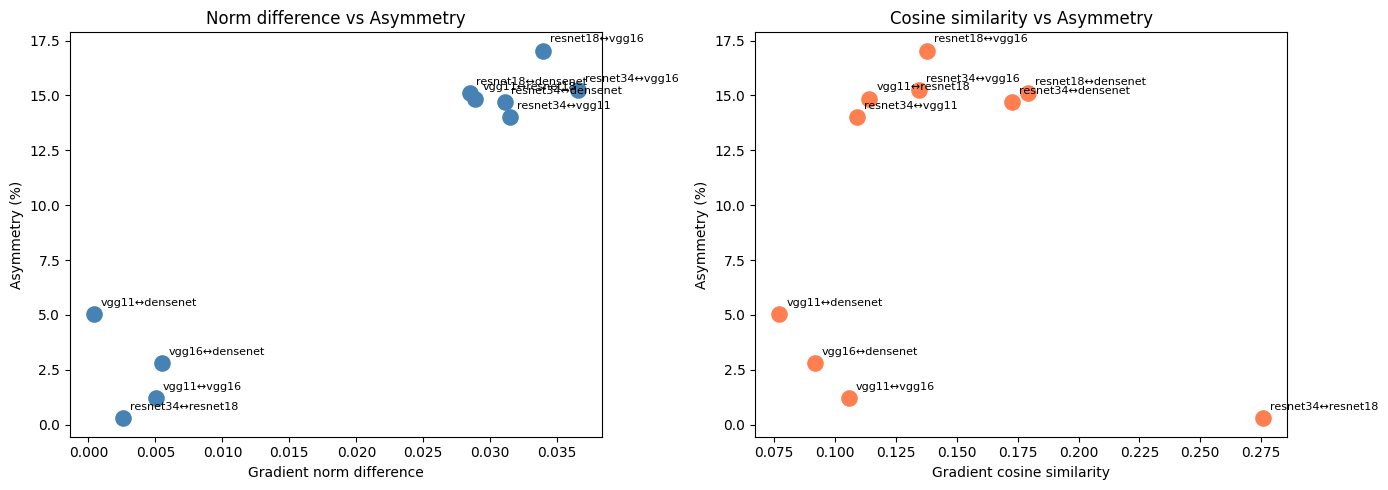

In [26]:
from itertools import combinations

pairs = list(combinations(MODEL_NAMES, 2))
norm_diffs = [abs(grad_norms[A] - grad_norms[B]) for A, B in pairs]
asym_vals = [asymmetry[(A, B)] for A, B in pairs]
cos_vals = [cosine_sims[(A, B)] for A, B in pairs]
pair_labels = [f"{A}↔{B}" for A, B in pairs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(norm_diffs, asym_vals, s=120, color='steelblue')
for i, lbl in enumerate(pair_labels):
    axes[0].annotate(lbl, (norm_diffs[i], asym_vals[i]),
                     textcoords="offset points", xytext=(5, 6), fontsize=8)
axes[0].set_xlabel("Gradient norm difference")
axes[0].set_ylabel("Asymmetry (%)")
axes[0].set_title("Norm difference vs Asymmetry")

axes[1].scatter(cos_vals, asym_vals, s=120, color='coral')
for i, lbl in enumerate(pair_labels):
    axes[1].annotate(lbl, (cos_vals[i], asym_vals[i]),
                     textcoords="offset points", xytext=(5, 6), fontsize=8)
axes[1].set_xlabel("Gradient cosine similarity")
axes[1].set_ylabel("Asymmetry (%)")
axes[1].set_title("Cosine similarity vs Asymmetry")

plt.tight_layout()
plt.savefig("../results/properties_vs_asymmetry.png", dpi=150)
plt.show()

In [27]:
import math

rows = []
for A, B in combinations(MODEL_NAMES, 2):
    fool_ab = round(100 - results[A][B], 2)
    fool_ba = round(100 - results[B][A], 2)
    
    # who transfers better and by how much
    dominant = A if fool_ab > fool_ba else B
    
    # param ratio (always >= 1)
    ratio = max(param_counts[A], param_counts[B]) / min(param_counts[A], param_counts[B])
    
    # log ratio — compresses the scale, easier to compare
    log_ratio = round(math.log10(ratio), 3)
    
    # accuracy difference
    acc_diff = round(abs(grad_norms[A] - grad_norms[B]), 4)

    rows.append({
        "Pair":             f"{A} ↔ {B}",
        "Fool A→B (%)":     fool_ab,
        "Fool B→A (%)":     fool_ba,
        "Dominant":         dominant,
        "Asymmetry (%)":    round(asymmetry[(A, B)], 2),
        "Norm diff":        round(abs(grad_norms[A] - grad_norms[B]), 4),
        "Cosine sim":       round(cosine_sims[(A, B)], 4),
        "Param ratio":      round(ratio, 1),
        "Log param ratio":  log_ratio,
    })

df_summary = pd.DataFrame(rows)
df_summary

,Pair,Fool A→B (%),Fool B→A (%),Dominant,Asymmetry (%),Norm diff,Cosine sim,Param ratio,Log param ratio
0,resnet34 ↔ vgg11,50.45,36.43,resnet34,14.02,0.0315,0.1089,6.1,0.782
1,resnet34 ↔ resnet18,77.76,78.05,resnet18,0.29,0.0026,0.2757,1.9,0.280
2,resnet34 ↔ vgg16,57.76,42.52,resnet34,15.24,0.0365,0.1347,6.3,0.800
3,resnet34 ↔ densenet,66.23,51.52,resnet34,14.71,0.0311,0.1729,3.1,0.485
4,vgg11 ↔ resnet18,36.26,51.12,resnet18,14.86,0.0289,0.1140,11.5,1.061
5,vgg11 ↔ vgg16,43.91,45.12,vgg16,1.21,0.0050,0.1058,1.0,0.018
6,vgg11 ↔ densenet,33.57,38.61,densenet,5.04,0.0004,0.0771,18.5,1.267
7,resnet18 ↔ vgg16,58.89,41.85,resnet18,17.04,0.0339,0.1376,12.0,1.080
8,resnet18 ↔ densenet,68.17,53.07,resnet18,15.10,0.0285,0.1793,1.6,0.206
9,vgg16 ↔ densenet,36.88,39.69,densenet,2.81,0.0055,0.0916,19.3,1.285


In [28]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear)
r_norm, p_norm = pearsonr(norm_diffs, asym_vals)
r_cos,  p_cos  = pearsonr(cos_vals, asym_vals)

print("=== Pearson Correlation ===")
print(f"Norm diff vs Asymmetry: r = {r_norm:.4f}, p = {p_norm:.4f}")
print(f"Cosine sim vs Asymmetry: r = {r_cos:.4f}, p = {p_cos:.4f}")

# Spearman correlation (rank-based, more robust)
s_norm, sp_norm = spearmanr(norm_diffs, asym_vals)
s_cos,  sp_cos  = spearmanr(cos_vals, asym_vals)

print("\n=== Spearman Correlation ===")
print(f"Norm diff vs Asymmetry: rho = {s_norm:.4f}, p = {sp_norm:.4f}")
print(f"Cosine sim vs Asymmetry: rho = {s_cos:.4f}, p = {sp_cos:.4f}")

=== Pearson Correlation ===
Norm diff vs Asymmetry: r = 0.9608, p = 0.0000
Cosine sim vs Asymmetry: r = -0.0843, p = 0.8169

=== Spearman Correlation ===
Norm diff vs Asymmetry: rho = 0.7939, p = 0.0061
Cosine sim vs Asymmetry: rho = 0.2727, p = 0.4458


In [29]:
from scipy.stats import pearsonr, spearmanr

# ---- parameter relationship ----
param_ratios = [max(param_counts[A], param_counts[B]) / min(param_counts[A], param_counts[B])
                for A, B in pairs]

log_param_ratios = [np.log10(r) for r in param_ratios]

# Pearson
r_param, p_param = pearsonr(log_param_ratios, asym_vals)

# Spearman
s_param, sp_param = spearmanr(log_param_ratios, asym_vals)

print("=== Parameter Ratio vs Asymmetry ===")
print(f"Pearson: r = {r_param:.4f}, p = {p_param:.4f}")
print(f"Spearman: rho = {s_param:.4f}, p = {sp_param:.4f}")

=== Parameter Ratio vs Asymmetry ===
Pearson: r = 0.1721, p = 0.6345
Spearman: rho = 0.2000, p = 0.5796
